In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

In [6]:
pd.set_option('display.max_rows', 1000)
PREFIX_PATH = "../../.."



baseline_sort = pd.read_csv(join(PREFIX_PATH, f"bench_results_sort_fp16.csv"))
baseline_sort["operator"] = "CANN"

radixsort_df_iter_16 = pd.read_csv(join(PREFIX_PATH, f"bench_results_radix_sort_128_fp16_iter_16.csv"))
radixsort_df_iter_16["operator"] = "Radix Sort (fp16, 16 iters)"
radixsort_df_iter_8 = pd.read_csv(join(PREFIX_PATH, f"bench_results_radix_sort_128_fp16_iter_8.csv"))
radixsort_df_iter_8["operator"] = "Radix Sort (fp16, 8 iters)"
radixsort_df_iter_4 = pd.read_csv(join(PREFIX_PATH, f"bench_results_radix_sort_128_fp16_iter_4.csv"))
radixsort_df_iter_4["operator"] = "Radix Sort (fp16, 4 iters)"


radixsort_df = pd.concat([baseline_sort, radixsort_df_iter_4, radixsort_df_iter_8, radixsort_df_iter_16])

radixsort_df['mem_bytes'] = (radixsort_df['size'] * 2)  + radixsort_df['outputsize'] * 2 + radixsort_df['outputsize'] * 2
radixsort_df['bandwidth_gbps'] = (radixsort_df['mem_bytes']) / (radixsort_df['time_us']*1000) #GB/s

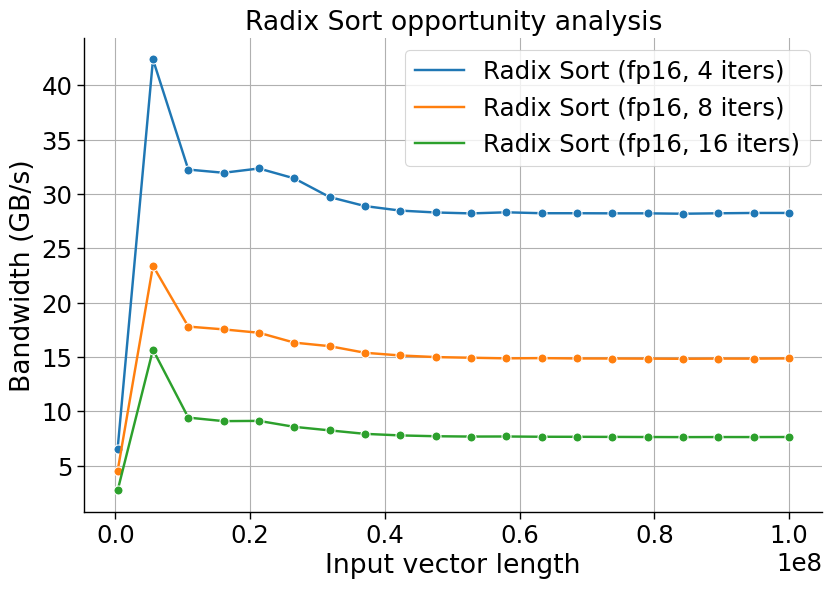

<Figure size 870x627 with 0 Axes>

In [7]:
ax = sns.lineplot(x='size', y='bandwidth_gbps', hue='operator', data=radixsort_df, marker='o')

ax.set_title(f"Radix Sort opportunity analysis")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/radix_sort_opportunity_fp16.png")
plt.show()
plt.clf()


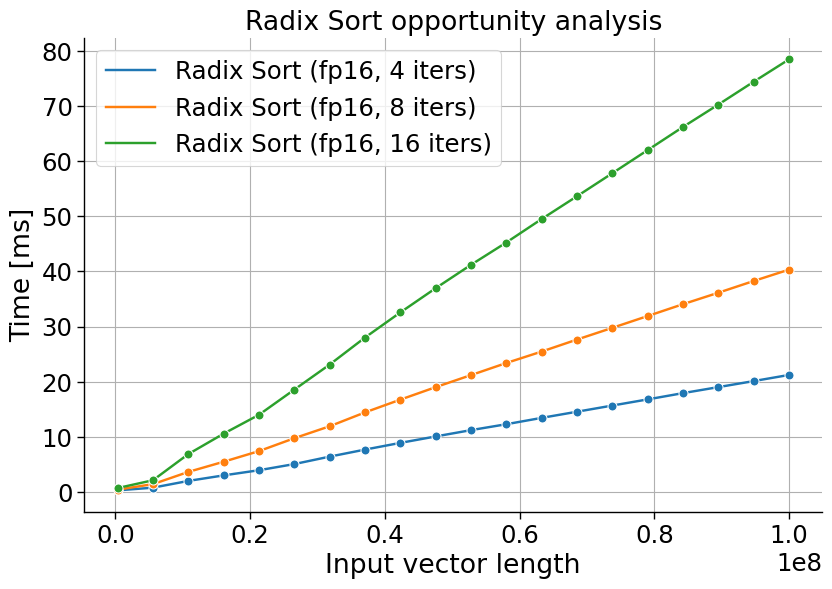

In [8]:
radixsort_df['time_ms'] = radixsort_df['time_us'] / 1000
ax = sns.lineplot(x='size', y='time_ms', hue='operator', data=radixsort_df, marker='o')

ax.set_title(f"Radix Sort opportunity analysis")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Time [ms]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()